In [1]:
import torch
print(f'PyTorch Version: {torch.__version__}')
print(f'CUDA Available: {torch.cuda.is_available()}')
print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch Version: 2.9.1+cu128
CUDA Available: True
GPU: NVIDIA GeForce RTX 5080


检查路径

In [111]:
import os
print(os.listdir('AngularPS/processed_tensors/202509'))

['valid_data.pt', 'label_stats.pt', 'train_data.pt', 'test_data.pt']


导入其余包

In [2]:
import torch.nn as nn
import torch.optim as optim
from torchmetrics import MeanAbsoluteError
from torch.utils.data import TensorDataset, DataLoader

导入数据

In [121]:
def load_data():
    # 加载训练数据
    train_data = torch.load('AngularPS/processed_tensors/202509/train_data.pt')
    train_dataset = TensorDataset(train_data['images'], train_data['labels'])
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    valid_data = torch.load('AngularPS/processed_tensors/202509/valid_data.pt')
    valid_dataset = TensorDataset(valid_data['images'], valid_data['labels'])
    valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=True)

    test_data = torch.load('AngularPS/processed_tensors/202509/test_data.pt')
    test_dataset = TensorDataset(test_data['images'], test_data['labels'])
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

    # 验证样本数量
    expected_sizes = {'train': 7200, 'valid': 900, 'test': 990}
    for dataset_type, dataset, data in [
        ('train', train_dataset, train_data),
        ('valid', valid_dataset, valid_data),
        ('test', test_dataset, test_data)
    ]:
        actual_size = len(dataset)
        expected_size = expected_sizes[dataset_type]
        if actual_size != expected_size:
            print(f"警告：{dataset_type} 数据集样本数量 ({actual_size}) 与预期 ({expected_size}) 不符！")

    print(train_data['images'].shape)  # 预期：(7200, 1, 20, 39)
    print(train_data['labels'].shape)  # 预期：(7200,)
    print(f"训练集: {len(train_dataset)} 样本, 数据形状 {train_dataset[0][0].shape}")
    print(f"验证集: {len(valid_dataset)} 样本, 数据形状 {valid_dataset[0][0].shape}")
    print(f"测试集: {len(test_dataset)} 样本, 数据形状 {test_dataset[0][0].shape}")
    return train_loader, valid_loader, test_loader

if __name__ == "__main__":
    train_loader, valid_loader, test_loader = load_data()

警告：test 数据集样本数量 (1332) 与预期 (990) 不符！
torch.Size([7200, 1, 20, 40])
torch.Size([7200, 2])
训练集: 7200 样本, 数据形状 torch.Size([1, 20, 40])
验证集: 900 样本, 数据形状 torch.Size([1, 20, 40])
测试集: 1332 样本, 数据形状 torch.Size([1, 20, 40])


定义CNN模型

In [122]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # 输入形状 (1, 20, 40)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # 输出 (32, 20, 40)
        self.bn1 = nn.BatchNorm2d(32)  # 批归一化
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)  # 输出 (32, 10, 20)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 输出 (64, 10, 20)
        self.bn2 = nn.BatchNorm2d(64)  # 批归一化
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)  # 输出 (64, 5, 10)
        self.flatten = nn.Flatten()
        # 计算全连接层输入维度：5 * 10 * 64 = 3200
        self.fc1 = nn.Linear(5 * 10 * 64, 256)  # 更新为3200
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.2)  # 可根据验证集性能调整到0.1-0.4
        self.fc2 = nn.Linear(256, 2)  # 双输出，回归任务 (klw, mcool)

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

定义训练函数

In [123]:
def r2_score(y_true, y_pred):
    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def train_model(model, train_loader, valid_loader, epochs=100, patience=30, w_klw=1.0, w_mcool=1):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = nn.MSELoss()  # 均方误差损失，适用于多输出回归
    mae = MeanAbsoluteError().to(device)  # MAE指标
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)  # 增加weight_decay

    best_valid_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_mae_klw, train_mae_mcool = 0.0, 0.0, 0.0
        valid_r2_klw, valid_mae_mcool = 0.0, 0.0
        train_samples = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)  # x: (batch_size, 1, 20, 40), y: (batch_size, 2)
            optimizer.zero_grad()
            output = model(x)  # output: (batch_size, 2)
            
            # 计算加权损失
            loss_klw = criterion(output[:, 0], y[:, 0]) * w_klw  # klw的损失
            loss_mcool = criterion(output[:, 1], y[:, 1]) * w_mcool  # mcool的损失
            loss = loss_klw + loss_mcool

            
            loss.backward()
            optimizer.step()
            
            # 累积损失和MAE
            train_loss += loss.item() * x.size(0)
            train_mae_klw += mae(output[:, 0], y[:, 0]).item() * x.size(0)
            train_mae_mcool += mae(output[:, 1], y[:, 1]).item() * x.size(0)
            train_samples += x.size(0)
        
        train_loss /= train_samples
        train_mae_klw /= train_samples
        train_mae_mcool /= train_samples

        # 验证阶段
        model.eval()
        valid_loss, valid_mae_klw, valid_mae_mcool = 0.0, 0.0, 0.0
        valid_samples = 0
        predictions = []
        trues = []
        with torch.no_grad():
            for x, y in valid_loader:
                x, y = x.to(device), y.to(device)
                output = model(x)  # output: (batch_size, 2)
                
                # 计算加权验证损失
                loss_klw = criterion(output[:, 0], y[:, 0]) * w_klw
                loss_mcool = criterion(output[:, 1], y[:, 1]) * w_mcool
                loss = loss_klw + loss_mcool
                
                valid_loss += loss.item() * x.size(0)
                valid_mae_klw += mae(output[:, 0], y[:, 0]).item() * x.size(0)
                valid_mae_mcool += mae(output[:, 1], y[:, 1]).item() * x.size(0)
                valid_samples += x.size(0)
                predictions.append(model(x.to(device)).cpu())
                trues.append(y.cpu())
        
        valid_loss /= valid_samples
        valid_mae_klw /= valid_samples
        valid_mae_mcool /= valid_samples
        all_pred = torch.cat(predictions, dim=0)
        all_true = torch.cat(trues, dim=0)
        valid_r2_klw = r2_score(all_true[:, 0], all_pred[:, 0])
        valid_r2_mcool = r2_score(all_true[:, 1], all_pred[:, 1])

        print(f'Epoch {epoch+1}/{epochs}, '
              f'Train Loss: {train_loss:.4f}, Train MAE klw: {train_mae_klw:.4f}, Train MAE mcool: {train_mae_mcool:.4f}, '
              f'Valid Loss: {valid_loss:.4f}, Valid MAE klw: {valid_mae_klw:.4f}, Valid MAE mcool: {valid_mae_mcool:.4f}, '
              f'Valid R2 klw: {valid_r2_klw:.4f}, Valid R2 mcool: {valid_r2_mcool:.4f}')

        # 保存最佳模型和早停
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), 'best_model100.pt')
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # 加载最佳模型
    model.load_state_dict(torch.load('best_model100.pt'))
    return model

定义测试函数

In [124]:
import numpy as np
np.random.seed(100000)

def test_model(model, test_loader, w_klw=1.0, w_mcool=1):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    criterion = nn.MSELoss()  # 均方误差损失，适用于多输出回归
    mae = MeanAbsoluteError().to(device)  # MAE指标
    test_loss, test_mae_klw, test_mae_mcool = 0.0, 0.0, 0.0
    test_samples = 0
    predictions, trues = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)  # x: (batch_size, 1, 20, 40), y: (batch_size, 2)
            output = model(x)  # output: (batch_size, 2)
            
            # 计算加权损失
            loss_klw = criterion(output[:, 0], y[:, 0]) * w_klw  # klw的损失
            loss_mcool = criterion(output[:, 1], y[:, 1]) * w_mcool  # mcool的损失
            loss = loss_klw + loss_mcool
            
            # 累积损失和MAE
            test_loss += loss.item() * x.size(0)
            test_mae_klw += mae(output[:, 0], y[:, 0]).item() * x.size(0)
            test_mae_mcool += mae(output[:, 1], y[:, 1]).item() * x.size(0)
            test_samples += x.size(0)
            
            # 存储预测和真实值
            predictions.append(model(x.to(device)).cpu())  # (batch_size, 2)
            trues.append(y.cpu())  # (batch_size, 2)
        all_pred = torch.cat(predictions, dim=0)
        all_true = torch.cat(trues, dim=0)
        test_r2_klw = r2_score(all_true[:, 0], all_pred[:, 0])
        test_r2_mcool = r2_score(all_true[:, 1], all_pred[:, 1])

    test_loss /= test_samples
    test_mae_klw /= test_samples
    test_mae_mcool /= test_samples
    predictions = np.concatenate(predictions, axis=0)  # 形状：(N, 2)
    trues = np.concatenate(trues, axis=0)  # 形状：(N, 2)

    print(f'Test Loss: {test_loss:.4f}, Test MAE klw: {test_mae_klw:.4f}, Test MAE mcool: {test_mae_mcool:.4f}, Test R2 klw: {test_r2_klw:.4f}, Test R2 mcool: {test_r2_mcool:.4f}')
    return test_loss, test_mae_klw, test_mae_mcool, predictions, trues

生成模型的流程图

In [9]:
from torchviz import make_dot

model = CNN()

model.eval()

# 创建一个示例输入（根据你的模型输入大小改）
x = torch.randn(1, 1, 20, 40)

# 前向传播
y = model(x)

# 生成结构图
dot = make_dot(y, params=dict(model.named_parameters()))
dot.format = "png"  # 或 "pdf"
dot.render("model_structure")
print("✅ 网络结构图已保存为 model_structure.png")

✅ 网络结构图已保存为 model_structure.png


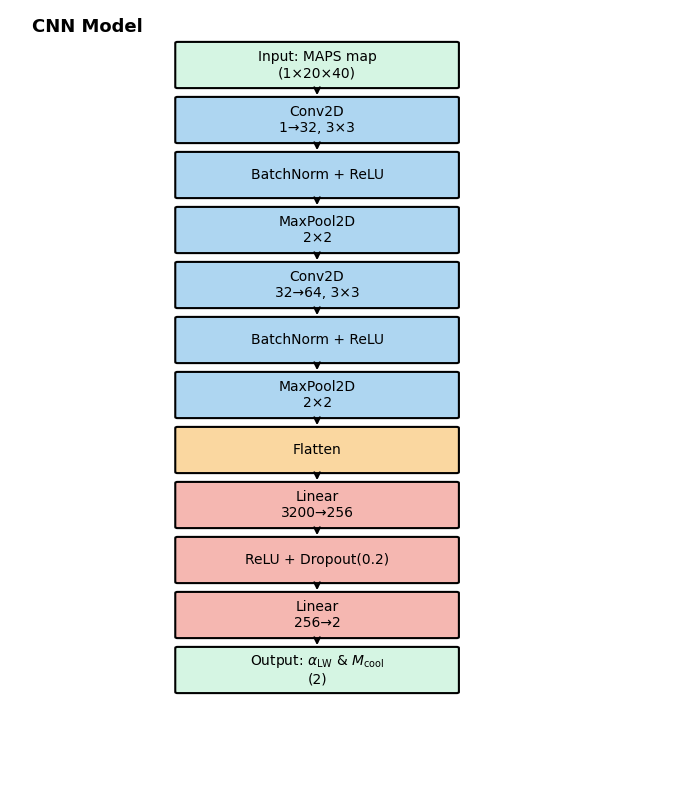

✅ 已生成修正版结构图：CNN_architecture_diagram_fixed.png


In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

def draw_box(ax, xy, text, width=2.5, height=0.8, color="#AED6F1"):
    x, y = xy
    box = FancyBboxPatch(
        (x, y - height / 2), width, height,
        boxstyle="round,pad=0.02",
        edgecolor="black",
        facecolor=color,
        linewidth=1.5
    )
    ax.add_patch(box)
    ax.text(x + width / 2, y, text, ha="center", va="center", fontsize=10)

def draw_arrow(ax, start, end):
    ax.annotate("",
                xy=end, xycoords='data',
                xytext=start, textcoords='data',
                arrowprops=dict(arrowstyle="->", lw=1.5))

def plot_cnn_architecture():
    fig, ax = plt.subplots(figsize=(7, 8))
    
    # --- Step 1: 扩大顶部空间，防止标题或坐标裁剪 ---
    ax.set_xlim(0, 6)
    ax.set_ylim(-1, 13)   # 原来是9，往上扩展一些
    ax.axis("off")

    # --- Step 2: 定义每一层（包括 Input 和 Conv2D） ---
    layers = [
        ("Input: MAPS map\n(1×20×40)", "#D5F5E3"),
        ("Conv2D\n1→32, 3×3", "#AED6F1"),
        ("BatchNorm + ReLU", "#AED6F1"),
        ("MaxPool2D\n2×2", "#AED6F1"),
        ("Conv2D\n32→64, 3×3", "#AED6F1"),
        ("BatchNorm + ReLU", "#AED6F1"),
        ("MaxPool2D\n2×2", "#AED6F1"),
        ("Flatten", "#FAD7A0"),
        ("Linear\n3200→256", "#F5B7B1"),
        ("ReLU + Dropout(0.2)", "#F5B7B1"),
        ("Linear\n256→2", "#F5B7B1"),
        ("Output: $\\alpha_{{\\mathrm{{LW}}}}$ & $M_{{\\mathrm{{cool}}}}$\n(2)", "#D5F5E3")
    ]

    # --- Step 3: 调整层的垂直布局，让最上层不被遮挡 ---
    y_positions = list(range(len(layers)))[::-1]
    y_positions = [y + 1 for y in y_positions]  # 整体往上移一点
    
    for i, ((text, color), y) in enumerate(zip(layers, y_positions)):
        draw_box(ax, (1.5, y), text, color=color)
        if i < len(layers) - 1:
            draw_arrow(ax, (2.75, y - 0.4), (2.75, y_positions[i+1] + 0.4))

    # 标题稍微下移一点，不遮盖 Input 框
    ax.text(0.2, y_positions[0] + 0.7, "CNN Model", fontsize=13, fontweight="bold", va="center")

    plt.tight_layout()
    plt.savefig("CNN_architecture_diagram.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    print("✅ 已生成修正版结构图：CNN_architecture_diagram_fixed.png")

plot_cnn_architecture()


主程序：加载数据、训练和测试

In [108]:
# 加载数据
train_loader, valid_loader, test_loader = load_data()

# 初始化模型
model = CNN()

# 训练（使用归一化标签，权重设为1.0）
model = train_model(model, train_loader, valid_loader, epochs=100, patience=20, w_klw=1.0, w_mcool=1.0)

# 加载最佳模型
model.load_state_dict(torch.load('best_model100.pt'))

# 测试
test_loss, test_mae_klw, test_mae_mcool, predictions, trues = test_model(model, test_loader, w_klw=1.0, w_mcool=1.0)

# 反归一化
label_stats = torch.load('AngularPS/processed_tensors/202509/label_stats.pt')
mean, std = label_stats['mean'], label_stats['std']
predictions = predictions * std.numpy() + mean.numpy()
trues = trues * std.numpy() + mean.numpy()

# 打印结果
print("部分测试集预测值与真实值（klw, mcool）：")
for i in range(min(5, len(predictions))):
    print(f"样本 {i+1}: 预测值=[{predictions[i, 0]:.4f}, {predictions[i, 1]:.4e}], "
          f"真实值=[{trues[i, 0]:.4f}, {trues[i, 1]:.4e}]")

警告：test 数据集样本数量 (1080) 与预期 (990) 不符！
torch.Size([7200, 1, 20, 40])
torch.Size([7200, 2])
训练集: 7200 样本, 数据形状 torch.Size([1, 20, 40])
验证集: 900 样本, 数据形状 torch.Size([1, 20, 40])
测试集: 1080 样本, 数据形状 torch.Size([1, 20, 40])
Epoch 1/100, Train Loss: 1.2834, Train MAE klw: 0.5883, Train MAE mcool: 0.6961, Valid Loss: 1.2597, Valid MAE klw: 0.6062, Valid MAE mcool: 0.7218, Valid R2 klw: 0.4878, Valid R2 mcool: 0.3042
Epoch 2/100, Train Loss: 1.0836, Train MAE klw: 0.5390, Train MAE mcool: 0.6663, Valid Loss: 1.2013, Valid MAE klw: 0.5889, Valid MAE mcool: 0.6610, Valid R2 klw: 0.4986, Valid R2 mcool: 0.3489
Epoch 3/100, Train Loss: 1.0644, Train MAE klw: 0.5392, Train MAE mcool: 0.6527, Valid Loss: 1.1580, Valid MAE klw: 0.5756, Valid MAE mcool: 0.6821, Valid R2 klw: 0.5159, Valid R2 mcool: 0.3731
Epoch 4/100, Train Loss: 1.0372, Train MAE klw: 0.5316, Train MAE mcool: 0.6448, Valid Loss: 1.1368, Valid MAE klw: 0.5897, Valid MAE mcool: 0.6670, Valid R2 klw: 0.5153, Valid R2 mcool: 0.3937
Epoch 5

测试集参数估计可视化

警告：test 数据集样本数量 (1332) 与预期 (990) 不符！
torch.Size([7200, 1, 20, 40])
torch.Size([7200, 2])
训练集: 7200 样本, 数据形状 torch.Size([1, 20, 40])
验证集: 900 样本, 数据形状 torch.Size([1, 20, 40])
测试集: 1332 样本, 数据形状 torch.Size([1, 20, 40])
Test Loss: 0.2592, Test MAE klw: 0.2817, Test MAE mcool: 0.2727, Test R2 klw: 0.7951, Test R2 mcool: 0.7913


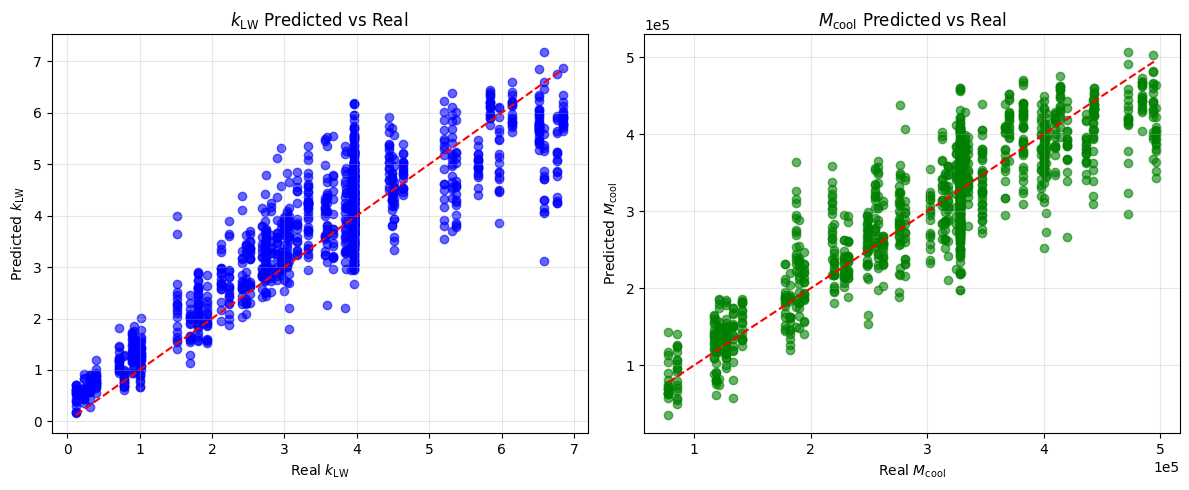

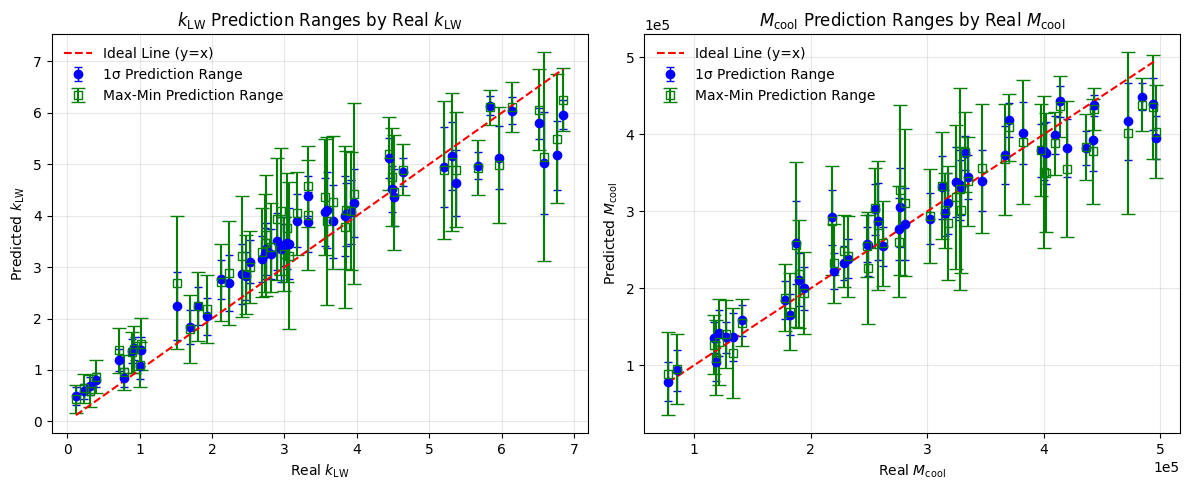

k_LW 分组统计（真实 k_LW -> 预测 k_LW 范围）：
k_LW_real=0.12: mean=0.4885, 1σ=[0.3114, 0.6657], max-min=[0.1722, 0.7083] (样本数: 18)
k_LW_real=0.23: mean=0.5881, 1σ=[0.4407, 0.7356], max-min=[0.3521, 0.9268] (样本数: 18)
k_LW_real=0.32: mean=0.6874, 1σ=[0.5207, 0.8542], max-min=[0.2707, 0.9050] (样本数: 18)
k_LW_real=0.40: mean=0.8052, 1σ=[0.6602, 0.9501], max-min=[0.5456, 1.1938] (样本数: 18)
k_LW_real=0.71: mean=1.1949, 1σ=[0.9849, 1.4050], max-min=[0.9495, 1.8214] (样本数: 18)
k_LW_real=0.79: mean=0.8486, 1σ=[0.6621, 1.0351], max-min=[0.6184, 1.2841] (样本数: 18)
k_LW_real=0.89: mean=1.3630, 1σ=[1.1295, 1.5965], max-min=[0.9475, 1.7325] (样本数: 18)
k_LW_real=0.92: mean=1.4175, 1σ=[1.1917, 1.6433], max-min=[0.9485, 1.8465] (样本数: 18)
k_LW_real=1.00: mean=1.0765, 1σ=[0.8185, 1.3346], max-min=[0.6621, 1.5414] (样本数: 18)
k_LW_real=1.02: mean=1.3824, 1σ=[1.1305, 1.6343], max-min=[1.0050, 2.0173] (样本数: 18)
k_LW_real=1.51: mean=2.2512, 1σ=[1.5910, 2.9114], max-min=[1.3993, 4.0011] (样本数: 18)
k_LW_real=1.70: mean=1.8360, 1σ

In [125]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# MODIFIED: 设置学术论文字体和样式（全局配置）
plt.rcParams['font.size'] = 10  # 默认字体大小10pt
plt.rcParams['axes.titlesize'] = 12  # 标题12pt
plt.rcParams['axes.labelsize'] = 10  # 轴标签10pt
plt.rcParams['xtick.labelsize'] = 10  # x轴刻度10pt
plt.rcParams['ytick.labelsize'] = 10  # y轴刻度10pt
plt.rcParams['legend.fontsize'] = 10  # 图例10pt
plt.rcParams['lines.linewidth'] = 1.5  # 线宽1.5pt
plt.rcParams['lines.markersize'] = 6  # 标记大小6pt

# 加载数据（仅测试集）
_, _, test_loader = load_data()

# 初始化模型并加载最佳权重
model = CNN()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.load_state_dict(torch.load('best_model100.pt'))
model.eval()

# 测试模型，获取预测和真实值
test_loss, test_mae_klw, test_mae_mcool, predictions, trues = test_model(model, test_loader, w_klw=1.0, w_mcool=1.0)

# 反归一化
label_stats = torch.load('AngularPS/processed_tensors/202509/label_stats.pt')
mean = label_stats['mean']  # [klw_mean, mcool_mean]
std = label_stats['std']    # [klw_std, mcool_std]
predictions = predictions * std.numpy() + mean.numpy()  # 形状: (900, 2)
trues = trues * std.numpy() + mean.numpy()             # 形状: (900, 2)

# 1. 可视化预测结果：散点图比较预测值 vs 真实值（保持原样，但受益于全局字体）
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# k_LW的散点图
axes[0].scatter(trues[:, 0], predictions[:, 0], alpha=0.6, color='blue')
axes[0].plot([trues[:, 0].min(), trues[:, 0].max()], [trues[:, 0].min(), trues[:, 0].max()], 'r--', lw=1.5)
axes[0].set_xlabel('Real $k_{\mathrm{LW}}$')
axes[0].set_ylabel('Predicted $k_{\mathrm{LW}}$')
axes[0].set_title('$k_{\mathrm{LW}}$ Predicted vs Real')
axes[0].grid(True, alpha=0.3)
# M_cool的散点图（使用科学计数法）
axes[1].scatter(trues[:, 1], predictions[:, 1], alpha=0.6, color='green')
axes[1].plot([trues[:, 1].min(), trues[:, 1].max()], [trues[:, 1].min(), trues[:, 1].max()], 'r--', lw=1.5)
axes[1].set_xlabel('Real $M_{\mathrm{cool}}$')
axes[1].set_ylabel('Predicted $M_{\mathrm{cool}}$')
axes[1].set_title('$M_{\mathrm{cool}}$ Predicted vs Real')
axes[1].ticklabel_format(style='sci', axis='both', scilimits=(0,0))  # 科学计数法
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('prediction_scatter_10000.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. 误差棒图：按真实值分组，计算对应预测值的范围（MODIFIED: 添加1sigma std范围）
# 第一张：按真实 k_LW 分组，计算预测 k_LW 的均值、std、max和min
unique_klw_real = np.unique(trues[:, 0])
unique_klw_real.sort()
mean_klw_pred = []  # MODIFIED: 新增均值
std_klw_pred = []   # MODIFIED: 新增标准差
max_klw_pred = []
min_klw_pred = []
sample_counts_klw = []
for klw_real in unique_klw_real:
    mask = np.isclose(trues[:, 0], klw_real, atol=1e-4)
    group_klw_preds = predictions[mask, 0]
    
    if len(group_klw_preds) > 1:  # MODIFIED: 至少2个样本才能计算std
        mean_klw_pred.append(np.mean(group_klw_preds))
        std_klw_pred.append(np.std(group_klw_preds))  # 1sigma = std
        max_klw_pred.append(np.max(group_klw_preds))
        min_klw_pred.append(np.min(group_klw_preds))
        sample_counts_klw.append(np.sum(mask))
    else:
        mean_klw_pred.append(np.nan)
        std_klw_pred.append(0)  # MODIFIED: std设为0，避免NaN
        max_klw_pred.append(np.nan)
        min_klw_pred.append(np.nan)
        sample_counts_klw.append(len(group_klw_preds))
mean_klw_pred = np.array(mean_klw_pred)
std_klw_pred = np.array(std_klw_pred)
max_klw_pred = np.array(max_klw_pred)
min_klw_pred = np.array(min_klw_pred)
sample_counts_klw = np.array(sample_counts_klw)

# 第二张：按真实 M_cool 分组，计算预测 M_cool 的均值、std、max和min
unique_mcool_real = np.unique(trues[:, 1])
unique_mcool_real.sort()
mean_mcool_pred = []  # MODIFIED: 新增均值
std_mcool_pred = []   # MODIFIED: 新增标准差
max_mcool_pred = []
min_mcool_pred = []
sample_counts_mcool = []
for mcool_real in unique_mcool_real:
    mask = np.isclose(trues[:, 1], mcool_real, atol=1e-4)
    group_mcool_preds = predictions[mask, 1]
    
    if len(group_mcool_preds) > 1:
        mean_mcool_pred.append(np.mean(group_mcool_preds))
        std_mcool_pred.append(np.std(group_mcool_preds))  # 1sigma = std
        max_mcool_pred.append(np.max(group_mcool_preds))
        min_mcool_pred.append(np.min(group_mcool_preds))
        sample_counts_mcool.append(np.sum(mask))
    else:
        mean_mcool_pred.append(np.nan)
        std_mcool_pred.append(0)
        max_mcool_pred.append(np.nan)
        min_mcool_pred.append(np.nan)
        sample_counts_mcool.append(len(group_mcool_preds))
mean_mcool_pred = np.array(mean_mcool_pred)
std_mcool_pred = np.array(std_mcool_pred)
max_mcool_pred = np.array(max_mcool_pred)
min_mcool_pred = np.array(min_mcool_pred)
sample_counts_mcool = np.array(sample_counts_mcool)

# 绘制误差棒图（MODIFIED: 双误差棒 + 学术样式）
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# 第一张：k_LW 误差棒图
# MODIFIED: 添加1sigma (std) 误差棒（蓝色，细线）
valid_idx_klw = ~np.isnan(mean_klw_pred)  # 只绘制有效组
axes[0].errorbar(unique_klw_real[valid_idx_klw], mean_klw_pred[valid_idx_klw], 
                 yerr=std_klw_pred[valid_idx_klw], fmt='o', capsize=3, color='blue', 
                 linewidth=1, elinewidth=1, markersize=6, label='1σ Prediction Range')
# 原max-min范围（绿色，粗线）
axes[0].errorbar(unique_klw_real[valid_idx_klw], (max_klw_pred[valid_idx_klw] + min_klw_pred[valid_idx_klw]) / 2, 
                 yerr=[(max_klw_pred[valid_idx_klw] - min_klw_pred[valid_idx_klw]) / 2], 
                 fmt='s', capsize=5, color='green', markerfacecolor='none', 
                 linewidth=1.5, elinewidth=1.5, markersize=6, label='Max-Min Prediction Range')
axes[0].plot(unique_klw_real, unique_klw_real, 'r--', lw=1.5, label='Ideal Line (y=x)')
axes[0].set_xlabel('Real $k_{\mathrm{LW}}$')
axes[0].set_ylabel('Predicted $k_{\mathrm{LW}}$')
axes[0].set_title('$k_{\mathrm{LW}}$ Prediction Ranges by Real $k_{\mathrm{LW}}$')
axes[0].legend(frameon=False)  # 无边框图例
axes[0].grid(True, alpha=0.3)

# 第二张：M_cool 误差棒图
# MODIFIED: 添加1sigma (std) 误差棒（蓝色，细线）
valid_idx_mcool = ~np.isnan(mean_mcool_pred)
axes[1].errorbar(unique_mcool_real[valid_idx_mcool], mean_mcool_pred[valid_idx_mcool], 
                 yerr=std_mcool_pred[valid_idx_mcool], fmt='o', capsize=3, color='blue', 
                 linewidth=1, elinewidth=1, markersize=6, label='1σ Prediction Range')
# 原max-min范围（绿色，粗线）
axes[1].errorbar(unique_mcool_real[valid_idx_mcool], (max_mcool_pred[valid_idx_mcool] + min_mcool_pred[valid_idx_mcool]) / 2, 
                 yerr=[(max_mcool_pred[valid_idx_mcool] - min_mcool_pred[valid_idx_mcool]) / 2], 
                 fmt='s', capsize=5, color='green', markerfacecolor='none', 
                 linewidth=1.5, elinewidth=1.5, markersize=6, label='Max-Min Prediction Range')
axes[1].plot(unique_mcool_real, unique_mcool_real, 'r--', lw=1.5, label='Ideal Line (y=x)')
axes[1].set_xlabel('Real $M_{\mathrm{cool}}$')
axes[1].set_ylabel('Predicted $M_{\mathrm{cool}}$')
axes[1].set_title('$M_{\mathrm{cool}}$ Prediction Ranges by Real $M_{\mathrm{cool}}$')
axes[1].ticklabel_format(style='sci', axis='both', scilimits=(0,0))  # 科学计数法
axes[1].legend(frameon=False)  # 无边框图例
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('error_bar_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# 打印分组统计（MODIFIED: 添加std信息）
print("k_LW 分组统计（真实 k_LW -> 预测 k_LW 范围）：")
for i, klw_real in enumerate(unique_klw_real):
    if not np.isnan(mean_klw_pred[i]):
        print(f"k_LW_real={klw_real:.2f}: mean={mean_klw_pred[i]:.4f}, 1σ=[{mean_klw_pred[i]-std_klw_pred[i]:.4f}, {mean_klw_pred[i]+std_klw_pred[i]:.4f}], "
              f"max-min=[{min_klw_pred[i]:.4f}, {max_klw_pred[i]:.4f}] (样本数: {sample_counts_klw[i]})")
print("\nM_cool 分组统计（真实 M_cool -> 预测 M_cool 范围）：")
for i, mcool_real in enumerate(unique_mcool_real):
    if not np.isnan(mean_mcool_pred[i]):
        print(f"M_cool_real={mcool_real:.4e}: mean={mean_mcool_pred[i]:.4e}, 1σ=[{mean_mcool_pred[i]-std_mcool_pred[i]:.4e}, {mean_mcool_pred[i]+std_mcool_pred[i]:.4e}], "
              f"max-min=[{min_mcool_pred[i]:.4e}, {max_mcool_pred[i]:.4e}] (样本数: {sample_counts_mcool[i]})")


选中的样本组：
真实 k_LW = 3.8500
真实 M_cool = 3.1300e+05 M_⊙
该组样本数量：18


/tmp/ipykernel_2493574/2985090649.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])


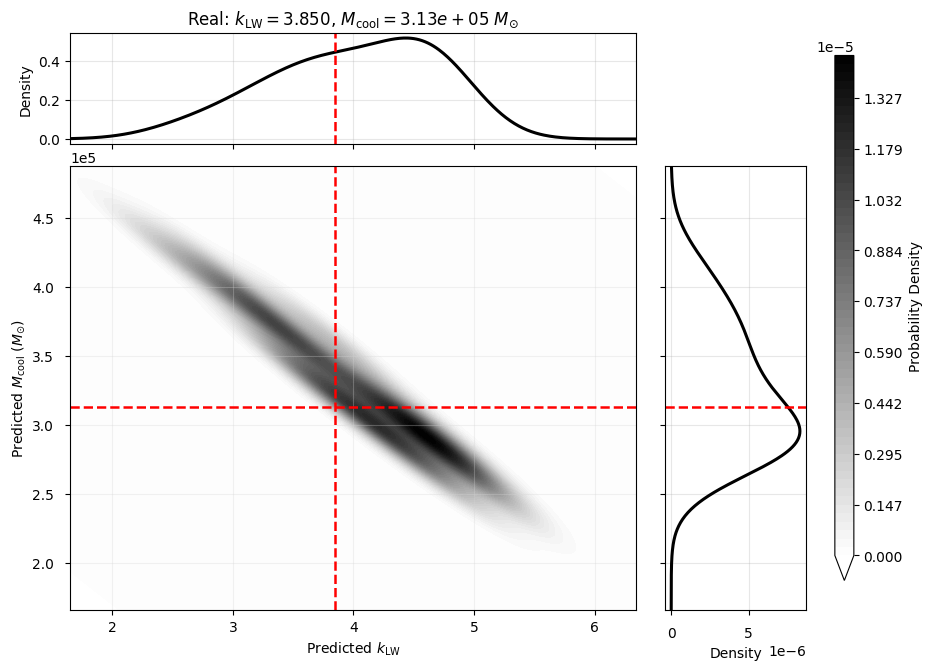


该组预测统计：
预测 k_LW:  mean = 3.998195 ± 0.633133
预测 M_cool: mean = 3.26545219e+05 ± 4.34110508e+04


In [ ]:
# ====================== 灰度版：低密度纯白色 + 高密度深黑 + 轴对齐 + 完整3σ ======================

from scipy.stats import gaussian_kde
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# 选取样本组（保持不变）
tol = 1e-6
trues_rounded = np.round(trues, decimals=8)
unique_combinations = np.unique(trues_rounded, axis=0)
unique_combinations = unique_combinations[np.lexsort((unique_combinations[:, 1], unique_combinations[:, 0]))]

selected_real_pair = unique_combinations[36]  # 可修改索引切换组
print(f"\n选中的样本组：")
print(f"真实 k_LW = {selected_real_pair[0]:.4f}")
print(f"真实 M_cool = {selected_real_pair[1]:.4e} M_⊙")

mask = np.all(np.isclose(trues, selected_real_pair, atol=tol), axis=1)
selected_predictions = predictions[mask]
sample_count = len(selected_predictions)
print(f"该组样本数量：{sample_count}")

pred_klw = selected_predictions[:, 0]
pred_mcool = selected_predictions[:, 1]

# ==================== 绘图 ====================
fig = plt.figure(figsize=(9.5, 7.5))
gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                       wspace=0.08, hspace=0.08)

# 主图 + 共享轴
ax_main = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# 计算 3.5σ 范围，确保完整显示分布
mean_klw, std_klw = np.mean(pred_klw), np.std(pred_klw)
mean_mcool, std_mcool = np.mean(pred_mcool), np.std(pred_mcool)

pad_sigma = 3.5
xmin = mean_klw - pad_sigma * std_klw
xmax = mean_klw + pad_sigma * std_klw
ymin = mean_mcool - pad_sigma * std_mcool
ymax = mean_mcool + pad_sigma * std_mcool

# 轻微额外边距
margin_x = 0.03 * (xmax - xmin)
margin_y = 0.03 * (ymax - ymin)
xmin -= margin_x
xmax += margin_x
ymin -= margin_y
ymax += margin_y

ax_main.set_xlim(xmin, xmax)
ax_main.set_ylim(ymin, ymax)

# 二维 KDE
kde = gaussian_kde(np.vstack([pred_klw, pred_mcool]))
X, Y = np.mgrid[xmin:xmax:400j, ymin:ymax:400j]
positions = np.vstack([X.ravel(), Y.ravel()])
Z = np.reshape(kde(positions).T, X.shape)

# 自定义灰度 colormap：低密度纯白 → 高密度深黑
base_cmap = plt.cm.gray_r  # 反转灰度（原gray_r是低值黑，高值白）
cmap_colors = base_cmap(np.linspace(0, 1, 256))
cmap_colors[0] = [1, 1, 1, 1]  # 强制最低密度为纯白
white_to_black = ListedColormap(cmap_colors)

levels = np.linspace(Z.min(), Z.max(), 60)
cf = ax_main.contourf(X, Y, Z, levels=levels, cmap=white_to_black, extend='min')

# 无等高线，只保留平滑填充

# 红色真实值线（在灰度图中红色仍很醒目）
ax_main.axvline(selected_real_pair[0], color='red', linestyle='--', linewidth=1.8)
ax_main.axhline(selected_real_pair[1], color='red', linestyle='--', linewidth=1.8)

ax_main.set_xlabel('Predicted $k_{\\mathrm{LW}}$')
ax_main.set_ylabel('Predicted $M_{\\mathrm{cool}}$ ($M_{\\odot}$)')
ax_main.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax_main.tick_params(axis='y', pad=8)
ax_main.grid(True, alpha=0.3, color='lightgray')

# 上方一维 KDE（深灰色与主图协调）
kde_klw = gaussian_kde(pred_klw)
x_klw = np.linspace(xmin, xmax, 400)
ax_top.plot(x_klw, kde_klw(x_klw), color='black', lw=2.2)
ax_top.axvline(selected_real_pair[0], color='red', linestyle='--', linewidth=1.8)
ax_top.set_ylabel('Density')
ax_top.set_title(f'Real: $k_{{\\mathrm{{LW}}}} = {selected_real_pair[0]:.3f}$, '
                 f'$M_{{\\mathrm{{cool}}}} = {selected_real_pair[1]:.2e}$ $M_{{\\odot}}$')
ax_top.grid(True, alpha=0.3)
ax_top.tick_params(labelbottom=False)

# 右侧一维 KDE
kde_mcool = gaussian_kde(pred_mcool)
y_mcool = np.linspace(ymin, ymax, 400)
ax_right.plot(kde_mcool(y_mcool), y_mcool, color='black', lw=2.2)
ax_right.axhline(selected_real_pair[1], color='red', linestyle='--', linewidth=1.8)
ax_right.set_xlabel('Density')
ax_right.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax_right.tick_params(axis='x', pad=8)
ax_right.tick_params(labelleft=False)
ax_right.grid(True, alpha=0.3)

# 颜色条
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
cbar = fig.colorbar(cf, cax=cbar_ax)
cbar.set_label('Probability Density')

plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.savefig('2d_prediction_density_nonoise.png', dpi=300, bbox_inches='tight')
plt.show()

# 输出统计
print(f"\n该组预测统计：")
print(f"预测 k_LW:  mean = {np.mean(pred_klw):.6f} ± {np.std(pred_klw):.6f}")
print(f"预测 M_cool: mean = {np.mean(pred_mcool):.8e} ± {np.std(pred_mcool):.8e}")

In [92]:
import pandas as pd
import numpy as np

# --- k_LW 分组：收集所有预测值 ---
klw_groups = []  # 存储每组的信息

for klw_real in unique_klw_real:
    mask = np.isclose(trues[:, 0], klw_real, atol=1e-4)
    group_preds = predictions[mask, 0]  # 该组所有预测的 k_LW 值
    
    if len(group_preds) > 0:  # 只保存有样本的组
        klw_groups.append({
            "k_LW_real": round(klw_real, 4),
            "sample_count": len(group_preds),
            "k_LW_pred_mean": np.mean(group_preds),
            "k_LW_pred_std": np.std(group_preds),
            "k_LW_pred_min": np.min(group_preds),
            "k_LW_pred_max": np.max(group_preds),
            "all_k_LW_predictions": group_preds.tolist()  # 保存所有单个预测值（列表）
        })

df_klw_full = pd.DataFrame(klw_groups)

# 保存为 CSV（pandas 会自动将列表转为字符串显示，但内容完整保留）
df_klw_full.to_csv("k_LW_group_stats_nonoise_new.csv", index=False)
print("已保存：k_LW_group_all_predictions.csv")
print(f"一共 {len(df_klw_full)} 个 k_LW 分组，每组所有预测值已完整保存。")
print(df_klw_full[['k_LW_real', 'sample_count', 'k_LW_pred_mean', 'k_LW_pred_std', 'k_LW_pred_min', 'k_LW_pred_max']])  # 预览统计列


# --- M_cool 分组：收集所有预测值 ---
mcool_groups = []

for mcool_real in unique_mcool_real:
    mask = np.isclose(trues[:, 1], mcool_real, atol=1e-4)
    group_preds = predictions[mask, 1]  # 该组所有预测的 M_cool 值
    
    if len(group_preds) > 0:
        mcool_groups.append({
            "M_cool_real": mcool_real,  # 科学计数法，保持原样
            "sample_count": len(group_preds),
            "M_cool_pred_mean": np.mean(group_preds),
            "M_cool_pred_std": np.std(group_preds),
            "M_cool_pred_min": np.min(group_preds),
            "M_cool_pred_max": np.max(group_preds),
            "all_M_cool_predictions": group_preds.tolist()  # 所有单个预测值
        })

df_mcool_full = pd.DataFrame(mcool_groups)

df_mcool_full.to_csv("M_cool_group_stats_nonoise_new.csv", index=False)
print("\n已保存：M_cool_group_all_predictions.csv")
print(f"一共 {len(df_mcool_full)} 个 M_cool 分组，每组所有预测值已完整保存。")
print(df_mcool_full[['M_cool_real', 'sample_count', 'M_cool_pred_mean', 'M_cool_pred_std', 'M_cool_pred_min', 'M_cool_pred_max']])

已保存：k_LW_group_all_predictions.csv
一共 53 个 k_LW 分组，每组所有预测值已完整保存。
    k_LW_real  sample_count  k_LW_pred_mean  k_LW_pred_std  k_LW_pred_min  \
0        0.12            18        0.605963       0.374484      -0.455717   
1        0.23            18        0.724456       0.177738       0.100595   
2        0.32            18        0.739854       0.223415       0.441018   
3        0.40            18        0.750707       0.322843       0.184206   
4        0.71            18        1.269025       0.236872       0.836106   
5        0.79            18        0.789284       0.212734       0.435923   
6        0.89            18        1.265379       0.237177       0.809461   
7        0.92            18        1.474686       0.330527       0.882885   
8        1.00            18        1.126307       0.162817       0.703244   
9        1.02            18        1.385215       0.310606       0.667950   
10       1.51            18        2.235673       0.402350       1.468411   
11       1.


选中的样本组：
真实 k_LW = 3.8500
真实 M_cool = 3.1300e+05 M_⊙
该组样本数量：18


/tmp/ipykernel_2493574/750594342.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])


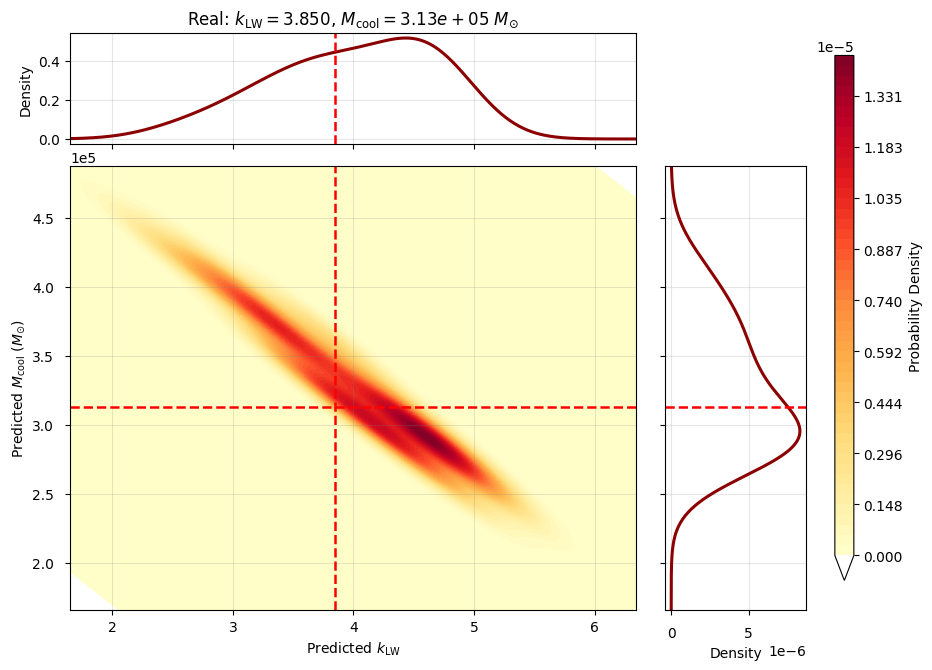


该组预测统计：
预测 k_LW:  mean = 3.998195 ± 0.633133
预测 M_cool: mean = 3.26545219e+05 ± 4.34110508e+04


In [ ]:
# ====================== 最终优化版：PD=0 纯白色 + YlOrRd 色系 + 轴对齐 + 完整3σ ======================

from scipy.stats import gaussian_kde
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# 选取样本组（保持不变）
tol = 1e-6
trues_rounded = np.round(trues, decimals=8)
unique_combinations = np.unique(trues_rounded, axis=0)
unique_combinations = unique_combinations[np.lexsort((unique_combinations[:, 1], unique_combinations[:, 0]))]

selected_real_pair = unique_combinations[36]  # 可修改索引切换组
print(f"\n选中的样本组：")
print(f"真实 k_LW = {selected_real_pair[0]:.4f}")
print(f"真实 M_cool = {selected_real_pair[1]:.4e} M_⊙")

mask = np.all(np.isclose(trues, selected_real_pair, atol=tol), axis=1)
selected_predictions = predictions[mask]
sample_count = len(selected_predictions)
print(f"该组样本数量：{sample_count}")

pred_klw = selected_predictions[:, 0]
pred_mcool = selected_predictions[:, 1]

# ==================== 绘图 ====================
fig = plt.figure(figsize=(9.5, 7.5))
gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                       wspace=0.08, hspace=0.08)

# 主图 + 共享轴
ax_main = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# 计算 3.5σ 范围，确保完整显示椭圆
mean_klw, std_klw = np.mean(pred_klw), np.std(pred_klw)
mean_mcool, std_mcool = np.mean(pred_mcool), np.std(pred_mcool)

pad_sigma = 3.5
xmin = mean_klw - pad_sigma * std_klw
xmax = mean_klw + pad_sigma * std_klw
ymin = mean_mcool - pad_sigma * std_mcool
ymax = mean_mcool + pad_sigma * std_mcool

# 轻微额外边距
margin_x = 0.03 * (xmax - xmin)
margin_y = 0.03 * (ymax - ymin)
xmin -= margin_x
xmax += margin_x
ymin -= margin_y
ymax += margin_y

ax_main.set_xlim(xmin, xmax)
ax_main.set_ylim(ymin, ymax)

# 二维 KDE
kde = gaussian_kde(np.vstack([pred_klw, pred_mcool]))
X, Y = np.mgrid[xmin:xmax:400j, ymin:ymax:400j]  # 高分辨率
positions = np.vstack([X.ravel(), Y.ravel()])
Z = np.reshape(kde(positions).T, X.shape)

# 新色系：YlOrRd + 强制最低值为纯白色
base_cmap = plt.cm.YlOrRd
cmap_colors = base_cmap(np.linspace(0, 1, 256))
cmap_colors[0] = [1, 1, 1, 1]  # PD=0 强制纯白
white_ylorrd = ListedColormap(cmap_colors)

levels = np.linspace(Z.min(), Z.max(), 50)  # 从实际最小值开始，确保低区白色
cf = ax_main.contourf(X, Y, Z, levels=levels, cmap=white_ylorrd, extend='min')

# 移除所有等高线（只保留平滑填充）

# 红色真实值线
ax_main.axvline(selected_real_pair[0], color='red', linestyle='--', linewidth=1.8)
ax_main.axhline(selected_real_pair[1], color='red', linestyle='--', linewidth=1.8)

ax_main.set_xlabel('Predicted $k_{\\mathrm{LW}}$')
ax_main.set_ylabel('Predicted $M_{\\mathrm{cool}}$ ($M_{\\odot}$)')
ax_main.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax_main.tick_params(axis='y', pad=8)
ax_main.grid(True, alpha=0.3, color='gray', lw=0.5)

# 上方一维 KDE（颜色与主图协调）
kde_klw = gaussian_kde(pred_klw)
x_klw = np.linspace(xmin, xmax, 400)
ax_top.plot(x_klw, kde_klw(x_klw), color='darkred', lw=2.2)
ax_top.axvline(selected_real_pair[0], color='red', linestyle='--', linewidth=1.8)
ax_top.set_ylabel('Density')
ax_top.set_title(f'Real: $k_{{\\mathrm{{LW}}}} = {selected_real_pair[0]:.3f}$, '
                 f'$M_{{\\mathrm{{cool}}}} = {selected_real_pair[1]:.2e}$ $M_{{\\odot}}$')
ax_top.grid(True, alpha=0.3)
ax_top.tick_params(labelbottom=False)

# 右侧一维 KDE
kde_mcool = gaussian_kde(pred_mcool)
y_mcool = np.linspace(ymin, ymax, 400)
ax_right.plot(kde_mcool(y_mcool), y_mcool, color='darkred', lw=2.2)
ax_right.axhline(selected_real_pair[1], color='red', linestyle='--', linewidth=1.8)
ax_right.set_xlabel('Density')
ax_right.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax_right.tick_params(axis='x', pad=8)
ax_right.tick_params(labelleft=False)
ax_right.grid(True, alpha=0.3)

# 颜色条（更长、更清晰）
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
cbar = fig.colorbar(cf, cax=cbar_ax)
cbar.set_label('Probability Density')

plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.savefig('2d_prediction_density_white_background_ylorrd.png', dpi=300, bbox_inches='tight')
plt.show()

# 输出统计
print(f"\n该组预测统计：")
print(f"预测 k_LW:  mean = {mean_klw:.6f} ± {std_klw:.6f}")
print(f"预测 M_cool: mean = {mean_mcool:.8e} ± {std_mcool:.8e}")


选中的样本组：
真实 k_LW = 3.9600
真实 M_cool = 3.2800e+05 M_⊙
该组样本数量：360


/tmp/ipykernel_2493574/3271103118.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])


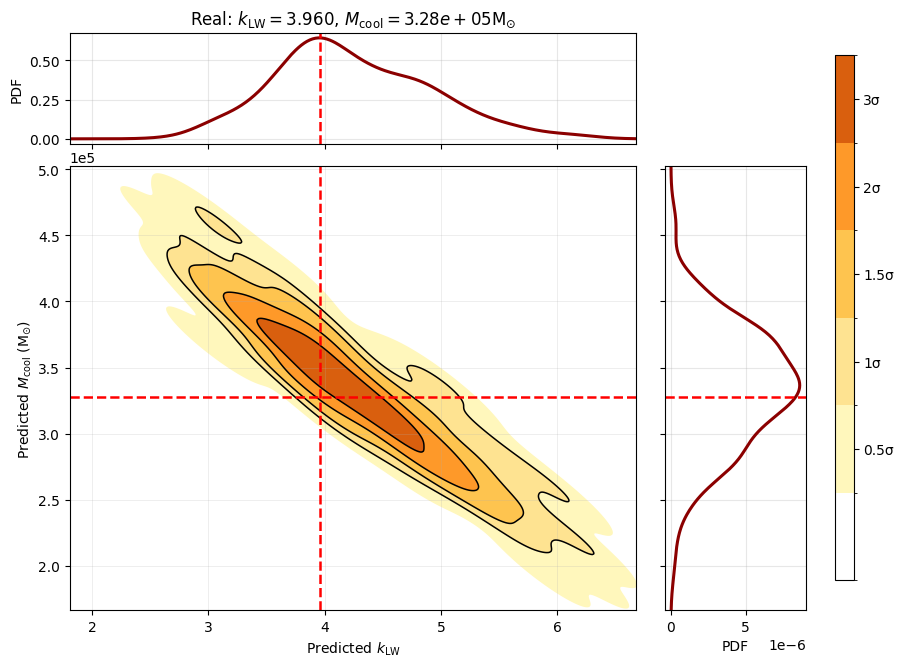


预测统计：
k_LW   = 4.243397 ± 0.656075
M_cool = 3.34411344e+05 ± 4.52793672e+04


In [126]:
# ====================== 最终方案：σ 阶梯纯色填充（地形图风格） ======================

from scipy.stats import gaussian_kde
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# ==================== 样本选择（保持不变） ====================
tol = 1e-6
trues_rounded = np.round(trues, decimals=8)
unique_combinations = np.unique(trues_rounded, axis=0)
unique_combinations = unique_combinations[np.lexsort(
    (unique_combinations[:, 1], unique_combinations[:, 0]))
]

selected_real_pair = unique_combinations[38]
print(f"\n选中的样本组：")
print(f"真实 k_LW = {selected_real_pair[0]:.4f}")
print(f"真实 M_cool = {selected_real_pair[1]:.4e} M_⊙")

mask = np.all(np.isclose(trues, selected_real_pair, atol=tol), axis=1)
selected_predictions = predictions[mask]
sample_count = len(selected_predictions)
print(f"该组样本数量：{sample_count}")

pred_klw = selected_predictions[:, 0]
pred_mcool = selected_predictions[:, 1]

# ==================== 画布布局 ====================
fig = plt.figure(figsize=(9.5, 7.5))
gs = gridspec.GridSpec(
    2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
    wspace=0.08, hspace=0.08
)

ax_main = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# ==================== 视野范围（完整 3.5σ） ====================
mean_klw, std_klw = np.mean(pred_klw), np.std(pred_klw)
mean_mcool, std_mcool = np.mean(pred_mcool), np.std(pred_mcool)

pad_sigma = 3.5
xmin = mean_klw - pad_sigma * std_klw
xmax = mean_klw + pad_sigma * std_klw
ymin = mean_mcool - pad_sigma * std_mcool
ymax = mean_mcool + pad_sigma * std_mcool

margin_x = 0.03 * (xmax - xmin)
margin_y = 0.03 * (ymax - ymin)
xmin -= margin_x
xmax += margin_x
ymin -= margin_y
ymax += margin_y

ax_main.set_xlim(xmin, xmax)
ax_main.set_ylim(ymin, ymax)

# ==================== 2D KDE ====================
kde = gaussian_kde(np.vstack([pred_klw, pred_mcool]))
X, Y = np.mgrid[xmin:xmax:400j, ymin:ymax:400j]
positions = np.vstack([X.ravel(), Y.ravel()])
Z = np.reshape(kde(positions).T, X.shape)

# ==================== σ 等概率区域计算（核心） ====================
Z_flat = Z.flatten()
idx = np.argsort(Z_flat)[::-1]
Z_sorted = Z_flat[idx]

cdf = np.cumsum(Z_sorted)
cdf /= cdf[-1]

sigma_probs = [0.393, 0.6827, 0.866, 0.9545, 0.9973]
pdf_levels = [Z_sorted[np.searchsorted(cdf, p)] for p in sigma_probs]

levels = [0.0] + sorted(pdf_levels) + [Z.max()]

# ==================== 离散纯色（地形图风格） ====================
sigma_colors = [
    "#ffffff",  # <0.5σ（背景）
    "#fff7bc",  # 0.5σ
    "#fee391",  # 1σ
    "#fec44f",  # 1.5σ
    "#fe9929",  # 2σ
    "#d95f0e",  # 3σ（核心）
]


cmap = ListedColormap(sigma_colors)
norm = BoundaryNorm(levels, cmap.N)

# ==================== 主图：σ 阶梯填色 ====================
cf = ax_main.contourf(
    X, Y, Z,
    levels=levels,
    cmap=cmap,
    norm=norm,
    antialiased=True
)

# σ 边界线（可选但强烈推荐）
ax_main.contour(
    X, Y, Z,
    levels=levels[2:-1],
    colors='k',
    linewidths=1.1
)

# ==================== 真实值 ====================
ax_main.axvline(selected_real_pair[0], color='red', ls='--', lw=1.8)
ax_main.axhline(selected_real_pair[1], color='red', ls='--', lw=1.8)

ax_main.set_xlabel('Predicted $k_{\\mathrm{LW}}$')
ax_main.set_ylabel('Predicted $M_{\\mathrm{cool}}$ ($\\mathrm{{M_{{\\odot}}}}$)')
ax_main.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax_main.grid(True, alpha=0.3, lw=0.5)

# ==================== 上方 1D KDE ====================
kde_klw = gaussian_kde(pred_klw)
x_klw = np.linspace(xmin, xmax, 400)
ax_top.plot(x_klw, kde_klw(x_klw), color='darkred', lw=2.2)
ax_top.axvline(selected_real_pair[0], color='red', ls='--', lw=1.8)
ax_top.set_ylabel('PDF')
ax_top.set_title(
    f'Real: $k_{{\\mathrm{{LW}}}}={selected_real_pair[0]:.3f}$, '
    f'$M_{{\\mathrm{{cool}}}}={selected_real_pair[1]:.2e} \\mathrm{{M_{{\\odot}}}}$'
)
ax_top.grid(True, alpha=0.3)
ax_top.tick_params(labelbottom=False)

# ==================== 右侧 1D KDE ====================
kde_mcool = gaussian_kde(pred_mcool)
y_mcool = np.linspace(ymin, ymax, 400)
ax_right.plot(kde_mcool(y_mcool), y_mcool, color='darkred', lw=2.2)
ax_right.axhline(selected_real_pair[1], color='red', ls='--', lw=1.8)
ax_right.set_xlabel('PDF')
ax_right.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
ax_right.tick_params(labelleft=False)
ax_right.grid(True, alpha=0.3)

# ==================== 颜色条（σ 标注） ====================
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
cbar = fig.colorbar(cf, cax=cbar_ax)
cbar.set_ticks([
    (levels[i] + levels[i+1]) / 2 for i in range(1, 6)
])

cbar.set_ticklabels([
    '0.5σ', '1σ', '1.5σ', '2σ', '3σ'
])

cbar.set_label(' ')

plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.savefig('2d_prediction_density_nonoise.pdf',
            dpi=300, bbox_inches='tight')
plt.show()

# ==================== 统计输出 ====================
print(f"\n预测统计：")
print(f"k_LW   = {mean_klw:.6f} ± {std_klw:.6f}")
print(f"M_cool = {mean_mcool:.8e} ± {std_mcool:.8e}")
